**Drive Mounted**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Loading The DataSet**

In [3]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/AILAB/archive (1)/iot23_combined.csv")
data.head()

,Unnamed: 0,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,service,duration,orig_bytes,...,conn_state_RSTOS0,conn_state_RSTR,conn_state_RSTRH,conn_state_S0,conn_state_S1,conn_state_S2,conn_state_S3,conn_state_SF,conn_state_SH,conn_state_SHR
0,0,1.525880e+09,CDe43c1PtgynajGI6,192.168.100.103,60905.0,131.174.215.147,23.0,-,2.998796,0,...,False,False,False,True,False,False,False,False,False,False
1,1,1.525880e+09,CJaDcG3MZzvf1YVYI4,192.168.100.103,44301.0,91.42.47.63,23.0,-,0.000000,0,...,False,False,False,True,False,False,False,False,False,False
2,2,1.525880e+09,CMBrup3BLXivSp4Avc,192.168.100.103,50244.0,120.210.108.200,23.0,-,0.000000,0,...,False,False,False,True,False,False,False,False,False,False
3,3,1.525880e+09,CfHl9r3XMYtDQRrHnh,192.168.100.103,34243.0,147.7.65.203,49560.0,-,2.998804,0,...,False,False,False,True,False,False,False,False,False,False
4,4,1.525880e+09,C7USrA15nFVkniMqC5,192.168.100.103,34840.0,145.164.35.6,21288.0,-,0.000000,0,...,False,False,False,True,False,False,False,False,False,False


**Explore Dataset**

In [4]:
print(data.shape)
print(data.info())
print(data['label'].value_counts())  # Check malicious vs benign


(1440315, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440315 entries, 0 to 1440314
Data columns (total 36 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Unnamed: 0         1440315 non-null  int64  
 1   ts                 1440315 non-null  float64
 2   uid                1440315 non-null  object 
 3   id.orig_h          1440315 non-null  object 
 4   id.orig_p          1440315 non-null  float64
 5   id.resp_h          1440315 non-null  object 
 6   id.resp_p          1440315 non-null  float64
 7   service            1440315 non-null  object 
 8   duration           1440315 non-null  float64
 9   orig_bytes         1440315 non-null  int64  
 10  resp_bytes         1440315 non-null  int64  
 11  local_orig         1440315 non-null  object 
 12  local_resp         1440315 non-null  object 
 13  missed_bytes       1440315 non-null  float64
 14  history            1440315 non-null  object 
 15  orig_pkts         

**Handle Missing Values (if any):**

In [5]:
data = data.dropna()  # or fill with median/mean


**Encode Labels:**

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])  # benign=0, malicious=1


**Feature Scaling:**

In [8]:
# Check data types
print(X.dtypes)

# Identify non-numeric columns
non_numeric_cols = X.select_dtypes(include=['object']).columns
print(non_numeric_cols)


Unnamed: 0             int64
ts                   float64
uid                   object
id.orig_h             object
id.orig_p            float64
id.resp_h             object
id.resp_p            float64
service               object
duration             float64
orig_bytes             int64
resp_bytes             int64
local_orig            object
local_resp            object
missed_bytes         float64
history               object
orig_pkts            float64
orig_ip_bytes        float64
resp_pkts            float64
resp_ip_bytes        float64
proto_icmp              bool
proto_tcp               bool
proto_udp               bool
conn_state_OTH          bool
conn_state_REJ          bool
conn_state_RSTO         bool
conn_state_RSTOS0       bool
conn_state_RSTR         bool
conn_state_RSTRH        bool
conn_state_S0           bool
conn_state_S1           bool
conn_state_S2           bool
conn_state_S3           bool
conn_state_SF           bool
conn_state_SH           bool
conn_state_SHR

In [9]:
# Drop columns like 'id', 'device', etc.
X = X.drop(columns=non_numeric_cols)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



**Step 3: Individual AI/ML/DL Models**

**Model 1: Random Forest (ML)**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Performance")
print(classification_report(y_test, y_pred_rf))


Random Forest Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39499
           1       1.00      1.00      1.00      3081
           2       1.00      1.00      1.00     27806
           3       1.00      1.00      1.00     52876
           4       1.00      1.00      1.00    164801

    accuracy                           1.00    288063
   macro avg       1.00      1.00      1.00    288063
weighted avg       1.00      1.00      1.00    288063



**Model 2: Neural Network (DL)**

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

nn_model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

y_pred_nn = (nn_model.predict(X_test) > 0.5).astype(int)

from sklearn.metrics import accuracy_score
print("NN Accuracy:", accuracy_score(y_test, y_pred_nn))


Epoch 1/10
28807/28807 ━━━━━━━━━━━━━━━━━━━━ 95s 3ms/step - accuracy: 0.0467 - loss: -16097591.0000 - val_accuracy: 0.0106 - val_loss: -204787456.0000
Epoch 2/10
28807/28807 ━━━━━━━━━━━━━━━━━━━━ 97s 3ms/step - accuracy: 0.0499 - loss: -398377280.0000 - val_accuracy: 0.0106 - val_loss: -1327831424.0000
Epoch 3/10
28807/28807 ━━━━━━━━━━━━━━━━━━━━ 135s 3ms/step - accuracy: 0.0499 - loss: -1882561920.0000 - val_accuracy: 0.0106 - val_loss: -4099301120.0000
Epoch 4/10
28807/28807 ━━━━━━━━━━━━━━━━━━━━ 87s 3ms/step - accuracy: 0.0501 - loss: -5191004160.0000 - val_accuracy: 0.0106 - val_loss: -9238795264.0000
Epoch 5/10
28807/28807 ━━━━━━━━━━━━━━━━━━━━ 130s 5ms/step - accuracy: 0.0499 - loss: -11038563328.0000 - val_accuracy: 0.0106 - val_loss: -17463132160.0000
Epoch 6/10
28807/28807 ━━━━━━━━━━━━━━━━━━━━ 99s 3ms/step - accuracy: 0.0492 - loss: -20158912512.0000 - val_accuracy: 0.0106 - val_loss: -29477398528.0000
Epoch 7/10
28807/28807 ━━━━━━━━━━━━━━━━━━━━ 87s 3ms/step - accuracy: 0.0495 - lo

**Step 4: Hybrid Model Development**

In [21]:
import numpy as np

y_pred_hybrid = np.round((y_pred_rf + y_pred_nn.flatten()) / 2)  # simple average voting
print("Hybrid Model Performance")
print(classification_report(y_test, y_pred_hybrid))


Hybrid Model Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39499
           1       1.00      1.00      1.00      3081
           2       0.11      1.00      0.20     27806
           3       0.00      0.00      0.00     52876
           4       0.00      0.00      0.00    164801

    accuracy                           0.24    288063
   macro avg       0.42      0.60      0.44    288063
weighted avg       0.16      0.24      0.17    288063



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Visualizations:**

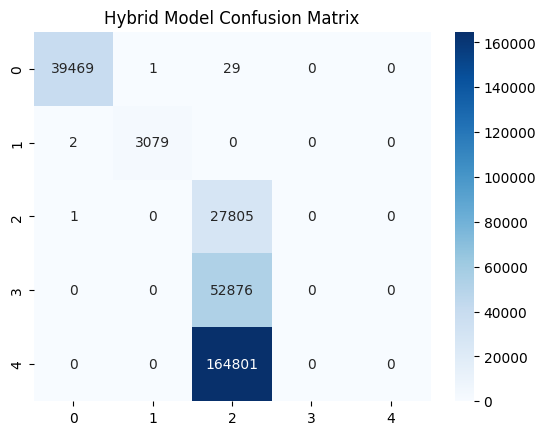

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_hybrid)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Hybrid Model Confusion Matrix")
plt.show()